In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv("advertising.csv")
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
num_cols = df.select_dtypes(include= 'number')
cat_cols = df.select_dtypes(include= 'object')

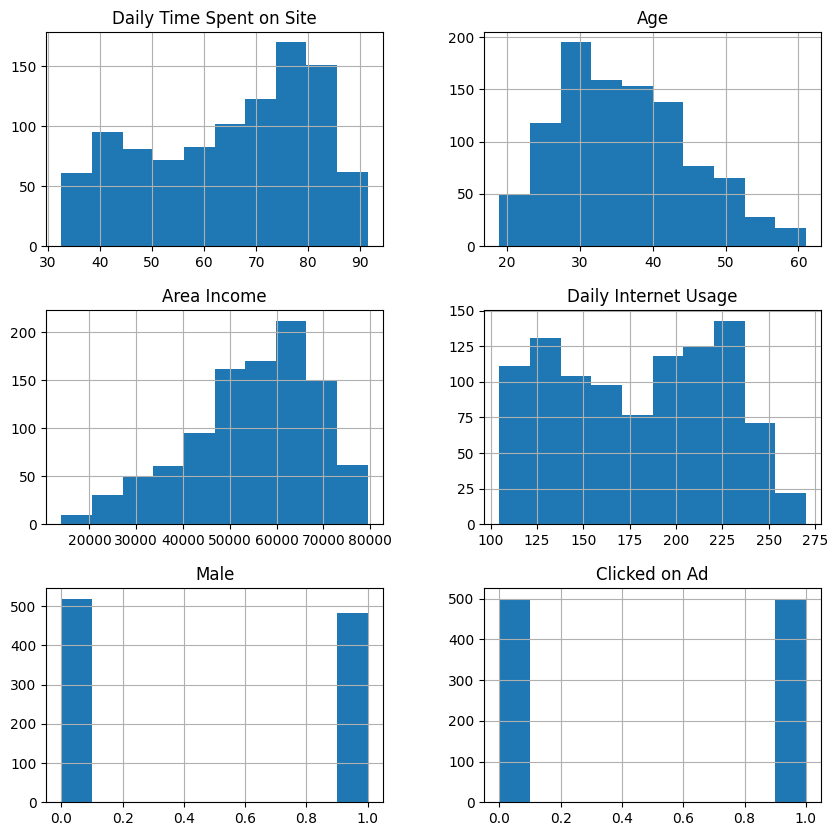

In [9]:
df.hist(figsize= (10,10))
plt.show()

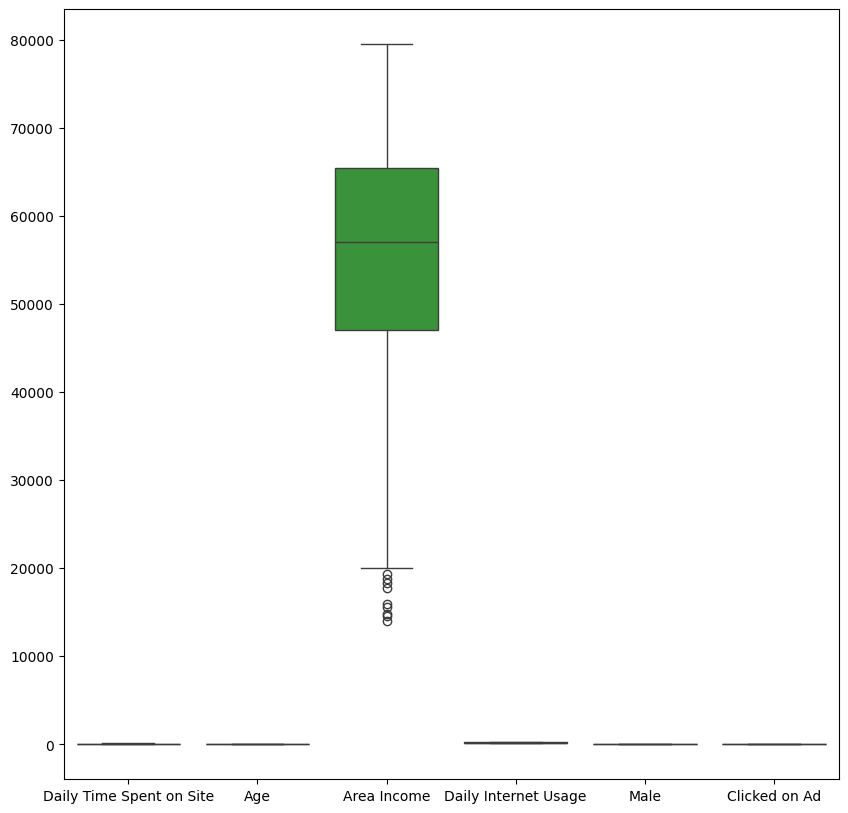

In [10]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df)
plt.show()

In [11]:
num_cols = ["Daily Time Spent on Site",
            "Age",
            "Area Income",
            "Daily Internet Usage"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [12]:
df.drop('Ad Topic Line', axis=1, inplace=True)
df.drop('City', axis=1, inplace=True)
df.drop('Country', axis=1, inplace=True)
df.drop('Timestamp', axis=1, inplace=True)

In [13]:
x = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [16]:
best_acc = 0
best_k = 0
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)

    pred = knn.predict(x_test)

    acc = accuracy_score(y_test, pred)

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Best K:", best_k)
print("Best Accuracy:", best_acc)

Best K: 6
Best Accuracy: 0.9849246231155779


In [17]:
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(x_train, y_train)
knn_pred = knn.predict(x_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))

Accuracy: 0.9849246231155779
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       103
           1       1.00      0.97      0.98        96

    accuracy                           0.98       199
   macro avg       0.99      0.98      0.98       199
weighted avg       0.99      0.98      0.98       199

[[103   0]
 [  3  93]]


In [19]:
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.989247311827957
Recall: 0.9583333333333334
F1 Score: 0.9735449735449735


In [20]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train, y_train)
nb_pred = nb.predict(x_test)

In [21]:
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))
print(confusion_matrix(y_test, nb_pred))

Accuracy: 0.9698492462311558
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       103
           1       0.97      0.97      0.97        96

    accuracy                           0.97       199
   macro avg       0.97      0.97      0.97       199
weighted avg       0.97      0.97      0.97       199

[[100   3]
 [  3  93]]


In [22]:
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.989247311827957
Recall: 0.9583333333333334
F1 Score: 0.9735449735449735


In [29]:
import joblib
joblib.dump(knn, "knn_model.pkl")
joblib.dump(nb, "nb_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [28]:
print(x.columns.tolist())

['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']
